Hydrostatic violation

In [73]:
from dataflows import load_dataset
from diagnostics import hydrostatic_balance_violation

# data from 12-step grid experiment
input_path_optim = "/home/users/f/froelicm/scratch/output/ian_12step_penalized_lr0001/target_31/input_epoch-8.nc"
input_data_optim = load_dataset(input_path_optim).isel(time=-1)

input_path = "/home/users/f/froelicm/scratch/output/ian_12step_penalized_lr0001/target_31/input_epoch-0.nc"
input_data = load_dataset(input_path).isel(time=-1)

lvl = 1000

z = input_data["geopotential"].sel(level=lvl).compute()
z_optim = input_data_optim["geopotential"].sel(level=lvl).compute()
rel_diff_origin = ((z_optim - z) / z)
print(f"mean: {rel_diff_origin.mean().item()}, max: {rel_diff_origin.max().item()}")
# get location of max relative diff: 
max_loc = rel_diff_origin.argmax(dim=["lat", "lon"])
print(f"max relative diff: location {z.lat.isel(lat=max_loc['lat']).item()}, {z.lon.isel(lon=max_loc['lon']).item()}")
print(f"analysis: {z.isel(max_loc).item()}")
print(f"prediction: {z_optim.isel(max_loc).item()}")

[DEBUG _normalize_lat_lon] is_wraparound flag: False, attrs: {}
[DEBUG _normalize_lat_lon] Applying normalization
[DEBUG _normalize_lat_lon] is_wraparound flag: False, attrs: {'long_name': '2 metre temperature', 'short_name': 't2m', 'standard_name': 'unknown', 'units': 'K'}
[DEBUG _normalize_lat_lon] Applying normalization
mean: -6.1013161030132324e-05, max: 21.625776290893555
max relative diff: location 55.0, 274.0
analysis: -0.039306640625
prediction: -0.88934326171875


In [67]:
hyd = hydrostatic_balance_violation(input_data)
hyd_optim = hydrostatic_balance_violation(input_data_optim)
rel_diff = ((hyd - hyd_optim)/hyd)["hydrostatic_balance_error"].compute()
print(f"mean: {rel_diff.mean().item()}, max: {rel_diff.max().item()}")

mean: -4.892147709321553e-06, max: 1604.6032908116608


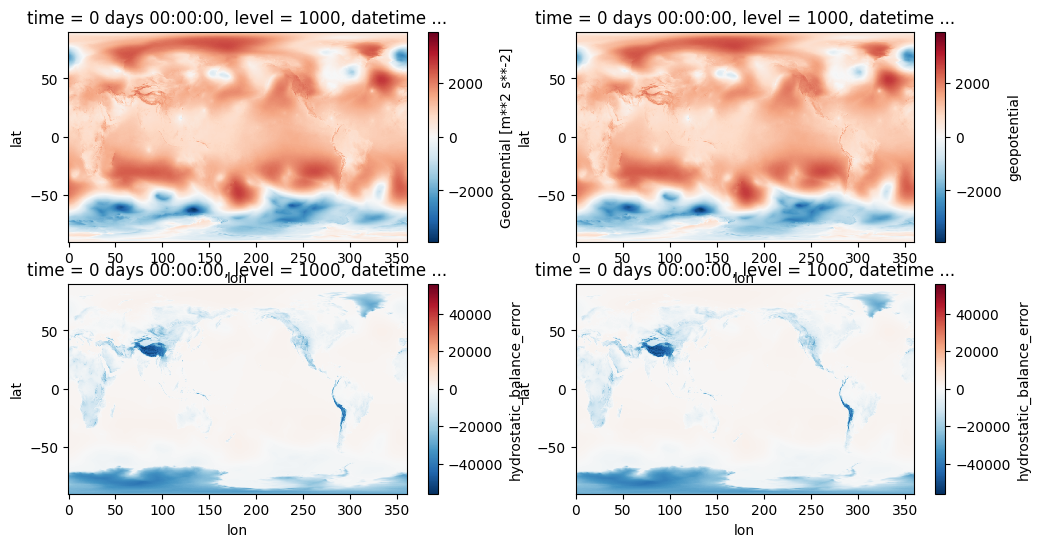

In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(12, 6))

input_data["geopotential"].sel(level=1000).plot(ax=ax[0, 0])
input_data_optim["geopotential"].sel(level=1000).plot(ax=ax[0, 1])

hyd["hydrostatic_balance_error"].sel(level=1000).plot(ax=ax[1, 0])
hyd_optim["hydrostatic_balance_error"].sel(level=1000).plot(ax=ax[1, 1])

# Turing Test debug

In [ ]:
import xarray 
import os 
from datetime import timedelta, datetime
from dataflows import _load_and_validate

# Data loading:
root = "/home/users/f/froelicm/share_scratch/turing_calibration/outputs/"
modules_list = ["Cast", "Cast", "Earth2Studio", "Earth2Studio", "Earth2Studio"]
models_list = ["graphcast_op", "graphcast_amse", "aurora_op", "fengwu_v2"]
init_dt = datetime(2022, 2, 15, 0)
max_lead_time = timedelta(days=10)

gt_path = f"/home/users/f/froelicm/share_scratch/hres_analysis/aifs_inputs_{init_dt.strftime('%Y_%m')}.nc"

# Data selection:
valid_times = slice(init_dt, init_dt + max_lead_time)
locations = [
    {"latitude": 17.5, "longitude": 300}, # atlantic
    {"latitude": 36, "longitude": 73.75}, # mountain
    {"latitude": 44.5, "longitude": 3.25}, # france
]
var_lvl = [("geopotential", 500), ("2m_temperature", None), ("u_component_of_wind", 850)]
variables = [x[0] for x in var_lvl]
levels = [x[1] for x in var_lvl if x[1] is not None]

ds = {}
for module, model in zip(modules_list,models_list):
    path = os.path.join(root, f"{module}_{model}_{init_dt.strftime('%Y_%m_%d_%H')}.nc")
    ds[model] = _load_and_validate(path).sel(pressure_level=levels).sel(valid_time=valid_times)[variables].compute()

gt = _load_and_validate(gt_path).sel(pressure_level=levels).sel(valid_time=valid_times)[variables].compute()
ds["HRES_fc0"] = gt

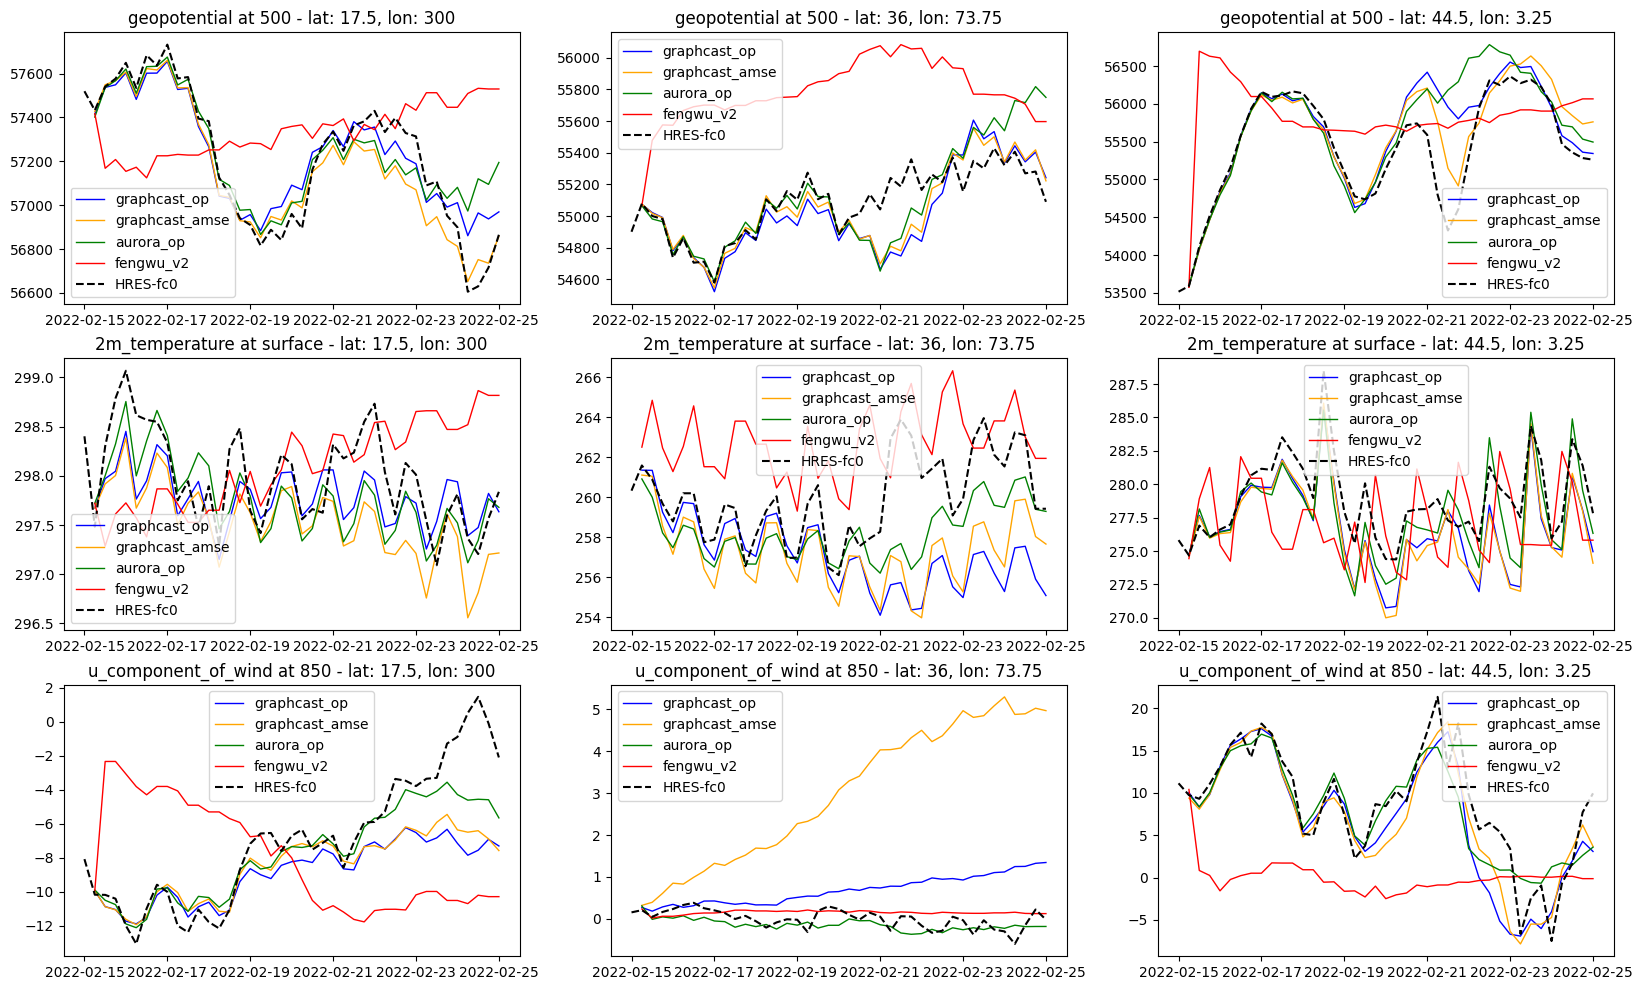

In [5]:
import matplotlib.pyplot as plt
import numpy as np

colors = ["blue", "orange", "green", "red", "black"]
widths = [1,1,1,1,1.5]
style = ["-", "-", "-", "-", "--"]

fig, axes = plt.subplots(len(var_lvl), len(locations), figsize=(20, 12))
for i, (var, lvl) in enumerate(var_lvl):
    for j, loc in enumerate(locations):
        for model, model_ds in ds.items():
            if lvl is not None:
                dat = model_ds[var].sel(latitude=loc["latitude"], longitude=loc["longitude"], pressure_level=lvl)
            else:
                dat = model_ds[var].sel(latitude=loc["latitude"], longitude=loc["longitude"]) 
            xaxis = [t - np.timedelta64(init_dt.hour, 'h') for t in list(dat.valid_time.values)]
            axes[i, j].plot(xaxis, dat.values, label=model, color=colors[list(ds.keys()).index(model)], linewidth=widths[list(ds.keys()).index(model)], linestyle=style[list(ds.keys()).index(model)])
        axes[i, j].set_title(f"{var} at {lvl if lvl else 'surface'} - lat: {loc['latitude']}, lon: {loc['longitude']}")
        axes[i, j].legend()

In [6]:
x = xarray.open_dataset("/home/users/f/froelicm/WeatherPlots/outputs/turing/mean_var_by_init_time_2022_2m_temperature_5_days_00:00:00.nc")

In [21]:
top_fails = list(np.sort(x.squeeze()["2m_temperature"].values))[-20:]
top_fails

[np.float64(3.678610400590295),
 np.float64(3.7254771458105167),
 np.float64(3.799633749602067),
 np.float64(3.8038171686511886),
 np.float64(3.833858807338542),
 np.float64(3.9743200650672437),
 np.float64(4.011597946959745),
 np.float64(4.027394237403194),
 np.float64(4.222709199508191),
 np.float64(4.2360433121513745),
 np.float64(4.318803871775103),
 np.float64(4.333537488864882),
 np.float64(4.58871924936076),
 np.float64(4.9397807994876395),
 np.float64(5.103991310999315),
 np.float64(5.588984285365617),
 np.float64(13.282740425590854),
 np.float64(14.830502846098877),
 np.float64(19.279980185036642),
 np.float64(19.53269921190349)]

In [22]:
top_fails_ind = [
    x["2m_temperature"].where(x["2m_temperature"] == fail).argmax().item() for fail in top_fails
]

In [23]:
{ind: x.init_time[ind].values for ind in top_fails_ind}

{165: np.datetime64('2022-02-11T12:00:00.000000000'),
 341: np.datetime64('2022-03-27T12:00:00.000000000'),
 140: np.datetime64('2022-02-05T06:00:00.000000000'),
 408: np.datetime64('2022-04-13T06:00:00.000000000'),
 174: np.datetime64('2022-02-13T18:00:00.000000000'),
 137: np.datetime64('2022-02-04T12:00:00.000000000'),
 400: np.datetime64('2022-04-11T06:00:00.000000000'),
 312: np.datetime64('2022-03-20T06:00:00.000000000'),
 302: np.datetime64('2022-03-17T18:00:00.000000000'),
 303: np.datetime64('2022-03-18T00:00:00.000000000'),
 311: np.datetime64('2022-03-20T00:00:00.000000000'),
 603: np.datetime64('2022-06-01T00:00:00.000000000'),
 358: np.datetime64('2022-03-31T18:00:00.000000000'),
 604: np.datetime64('2022-06-01T06:00:00.000000000'),
 118: np.datetime64('2022-01-30T18:00:00.000000000'),
 291: np.datetime64('2022-03-15T00:00:00.000000000'),
 119: np.datetime64('2022-01-31T00:00:00.000000000'),
 122: np.datetime64('2022-01-31T18:00:00.000000000'),
 121: np.datetime64('2022-01

Debugging with HRES fc0 vs. HRES analysis

In [1]:
test_date = "2022-02-04T12"

In [3]:
import xarray 
import os 
from datetime import timedelta, datetime
from dataflows import _load_and_validate

# Data loading:
root_analysis = "/home/users/f/froelicm/share_scratch/turing_calibration/outputs/"
root_f0 = "/home/users/f/froelicm/share_scratch/turing_calibration_hres_t0/outputs/"
modules_list = ["Earth2Studio", "Earth2Studio", "Earth2Studio", "Cast"]
models_list = ["aurora_op", "fengwu_v2", "aifs_v1", "graphcast_op"]
init_dt = datetime.fromisoformat(test_date)
max_lead_time = timedelta(days=7)

gt_analysis_path = f"/home/users/f/froelicm/share_scratch/hres_analysis/aifs_inputs_{init_dt.strftime('%Y_%m')}.nc"
gt_f0_path = f"/home/users/f/froelicm/share_scratch/hres_fc_step0/aifs_inputs_{init_dt.strftime('%Y_%m')}.nc"

# Data selection:
valid_times = slice(init_dt, init_dt + max_lead_time)
locations = [
    {"latitude": 17.5, "longitude": 300}, # atlantic
    {"latitude": 36, "longitude": 73.75}, # mountain
    {"latitude": 44.5, "longitude": 3.25}, # france
]
var_lvl = [("geopotential", 500), ("2m_temperature", None), ("u_component_of_wind", 850)]
variables = [x[0] for x in var_lvl]
levels = [x[1] for x in var_lvl if x[1] is not None]

ds = {}
for module, model in zip(modules_list,models_list):
    path = os.path.join(root_analysis, f"{module}_{model}_{init_dt.strftime('%Y_%m_%d_%H')}.nc")
    if os.path.exists(path): 
        ds[model+"_analysis"] = _load_and_validate(path).sel(pressure_level=levels).sel(valid_time=valid_times)[variables].compute()
    else: 
        print(f"Warning: {model+"_analysis"} at {path} not found.")

for module, model in zip(modules_list,models_list):
    path = os.path.join(root_f0, f"{module}_{model}_{init_dt.strftime('%Y_%m_%d_%H')}.nc")
    if os.path.exists(path):
        ds[model+"_fc0"] = _load_and_validate(path).sel(pressure_level=levels).sel(valid_time=valid_times)[variables].compute()
    else:
        print(f"Warning: {model+"_fc0"} at {path} not found.")

gt_analysis = _load_and_validate(gt_analysis_path).sel(pressure_level=levels).sel(valid_time=valid_times)[variables].compute()
ds["HRES_analysis"] = gt_analysis
gt_f0 = _load_and_validate(gt_f0_path).sel(pressure_level=levels).sel(valid_time=valid_times)[variables].compute()
ds["HRES_fc0"] = gt_f0

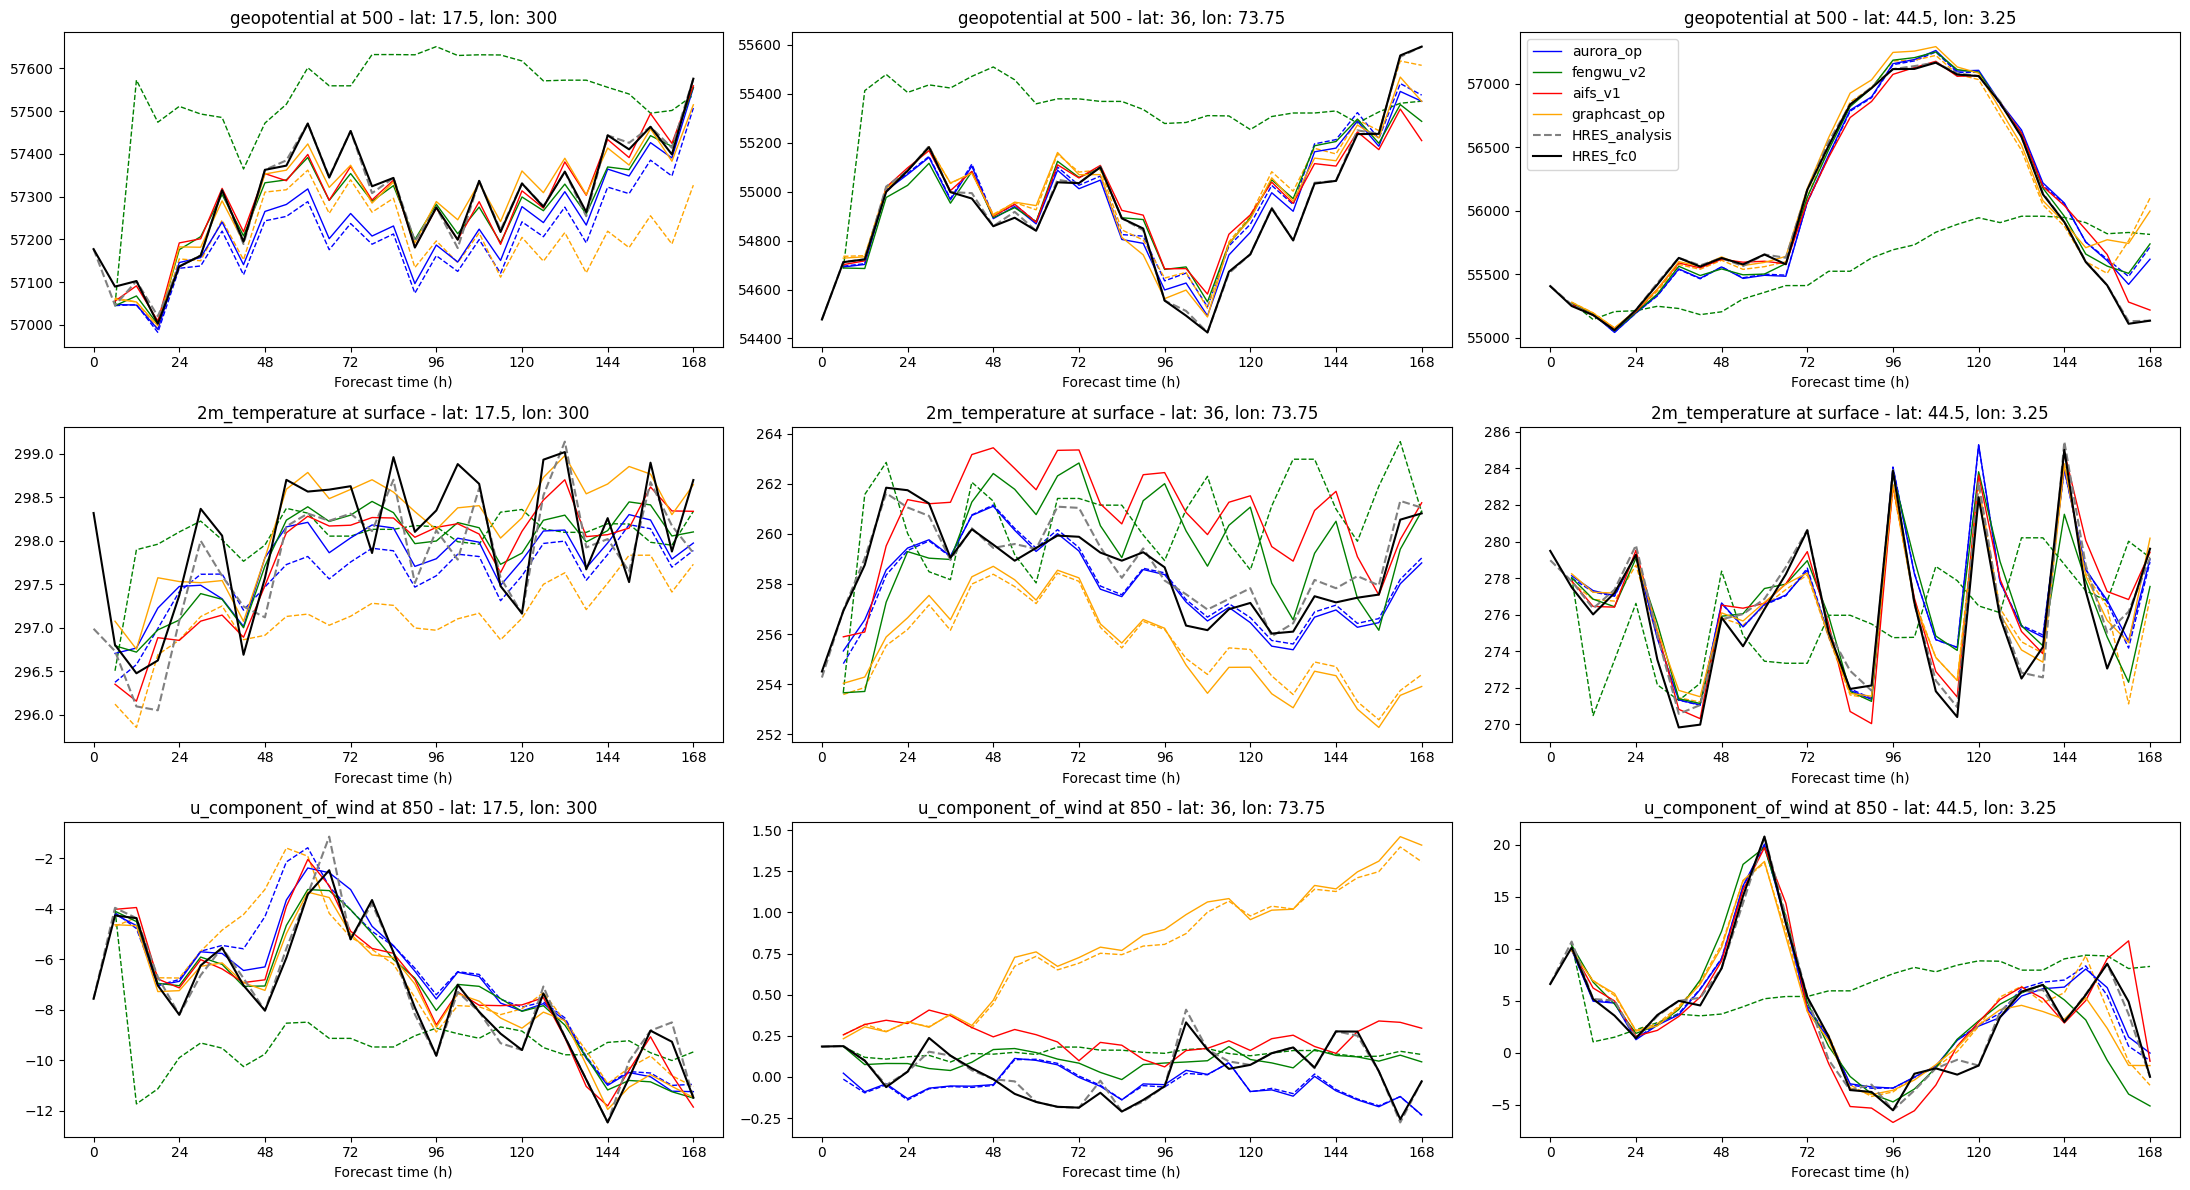

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

colors = {
    "aurora_op_analysis": "blue",
    "aurora_op_fc0": "blue",
    "fengwu_v2_analysis": "green",
    "fengwu_v2_fc0": "green",
    "aifs_v1_analysis": "red",
    "aifs_v1_fc0": "red",
    "graphcast_op_analysis": "orange",
    "graphcast_op_fc0": "orange",
    "HRES_analysis": "grey",
    "HRES_fc0": "black"
}
widths = {
    "aurora_op_analysis": 1,
    "aurora_op_fc0": 1,
    "fengwu_v2_analysis": 1,
    "fengwu_v2_fc0": 1,
    "aifs_v1_analysis": 1,
    "aifs_v1_fc0": 1,
    "graphcast_op_analysis": 1,
    "graphcast_op_fc0": 1,
    "HRES_analysis": 1.5,
    "HRES_fc0": 1.5
}
styles = {
    "aurora_op_analysis": "--",
    "aurora_op_fc0": "-",
    "fengwu_v2_analysis": "--",
    "fengwu_v2_fc0": "-",
    "aifs_v1_analysis": "--",
    "aifs_v1_fc0": "-",
    "graphcast_op_analysis": "--",
    "graphcast_op_fc0": "-",
    "HRES_analysis": "--",
    "HRES_fc0": "-"
}

fig, axes = plt.subplots(len(var_lvl), len(locations), figsize=(22, 12))
for i, (var, lvl) in enumerate(var_lvl):
    for j, loc in enumerate(locations):
        xaxis = 0
        for model, model_ds in ds.items():
            if lvl is not None:
                dat = model_ds[var].sel(latitude=loc["latitude"], longitude=loc["longitude"], pressure_level=lvl)
            else:
                dat = model_ds[var].sel(latitude=loc["latitude"], longitude=loc["longitude"]) 
            xaxis = [(pd.to_datetime(pd.Timestamp(t)) - init_dt).total_seconds()/3600 for t in dat.valid_time.data]
            _model = model.split("_")
            axes[i, j].plot(
                xaxis, dat.values, 
                label=f"{_model[0]}_{_model[1]}" if _model[-1] == "fc0" or _model[0] == "HRES" else None, 
                color=colors[model], 
                linewidth=widths[model], 
                linestyle=styles[model]
            )

        axes[i, j].set_xlabel("Forecast time (h)")
        axes[i, j].set_xticks(np.arange(0, xaxis[-1] + 24, 24))
        axes[i, j].set_title(f"{var} at {lvl if lvl else 'surface'} - lat: {loc['latitude']}, lon: {loc['longitude']}")
        if i==0 and j==2:
            axes[i, j].legend()

fig.tight_layout()